In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster(n_workers=4, threads_per_worker=1,  memory_limit='6GB')
client = Client(cluster)

In [2]:
import xarray as xr
import numpy as np

# ============================================================
# FILES
# ============================================================

data_dir = "/work/users/mccorda/data"

files = {
    "ICON": {
        "u": f"{data_dir}/atmosphere3d.seasonal_climatology.climatedt-gen2.ICON-5km.baseline-hist.r1.u.nc",
        "v": f"{data_dir}/atmosphere3d.seasonal_climatology.climatedt-gen2.ICON-5km.baseline-hist.r1.v.nc",
    },
    "IFS-FESOM": {
        "u": f"{data_dir}/atmosphere3d.seasonal_climatology.climatedt-gen2.IFS-FESOM-5km.baseline-hist.r1.u.nc",
        "v": f"{data_dir}/atmosphere3d.seasonal_climatology.climatedt-gen2.IFS-FESOM-5km.baseline-hist.r1.v.nc",
    },
    "IFS-NEMO": {
        "u": f"{data_dir}/atmosphere3d.seasonal_climatology.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.u.nc",
        "v": f"{data_dir}/atmosphere3d.seasonal_climatology.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.v.nc",
    },
    "ERA5": {
        "u": f"{data_dir}/atmosphere3d.seasonal_climatology.obs.ERA5.era5.r1.u.nc",
        "v": f"{data_dir}/atmosphere3d.seasonal_climatology.obs.ERA5.era5.r1.v.nc",
    },
}

In [5]:
import xarray as xr
import numpy as np


def compute_shear(files_uv, hemisphere):

    # --------------------------------------------------------
    # Open u and v together
    # --------------------------------------------------------
    ds = xr.open_mfdataset(
        [files_uv["u"], files_uv["v"]],
        combine="by_coords"
    )

    # --------------------------------------------------------
    # Select seasons and hemisphere
    # --------------------------------------------------------
    if hemisphere == "NH":
        seasons = ["JJA", "SON"]
        lat_mask = ds.lat > 0

    elif hemisphere == "SH":
        seasons = ["DJF", "MAM"]
        lat_mask = ds.lat < 0

    else:
        raise ValueError("hemisphere must be 'NH' or 'SH'")

    ds = ds.sel(season=seasons)

    # --------------------------------------------------------
    # Seasonal mean
    # --------------------------------------------------------
    ds = ds.mean(dim="season")

    # --------------------------------------------------------
    # Select hemisphere spatially
    # --------------------------------------------------------
    ds = ds.where(lat_mask, drop=True)

    # --------------------------------------------------------
    # Select 850 and 250 hPa
    # --------------------------------------------------------
    u850 = ds["u"].sel(plev=85000)
    u250 = ds["u"].sel(plev=25000)

    v850 = ds["v"].sel(plev=85000)
    v250 = ds["v"].sel(plev=25000)

    # Remove the scalar plev coordinate
    u850 = u850.drop_vars("plev")
    u250 = u250.drop_vars("plev")
    v850 = v850.drop_vars("plev")
    v250 = v250.drop_vars("plev")

    # --------------------------------------------------------
    # Vertical wind shear components
    # --------------------------------------------------------
    ud = u850 - u250
    vd = v850 - v250

    # --------------------------------------------------------
    # Shear magnitude
    # --------------------------------------------------------
    Vd = np.sqrt(ud**2 + vd**2)

    # --------------------------------------------------------
    # Return dataset
    # --------------------------------------------------------
    return xr.Dataset({
        "u850": u850,
        "u250": u250,
        "v850": v850,
        "v250": v250,
        "ud": ud,
        "vd": vd,
        "Vd": Vd,
    })

In [6]:
shear = {}

for model, f in files.items():

    shear[model] = {
        "NH": compute_shear(f, "NH"),
        "SH": compute_shear(f, "SH"),
    }

In [9]:
print(shear["IFS-FESOM"]["NH"]["Vd"])
print(shear["IFS-FESOM"]["NH"]["ud"])
print(shear["IFS-FESOM"]["SH"]["Vd"])

<xarray.DataArray 'Vd' (lat: 90, lon: 360)> Size: 259kB
dask.array<sqrt, shape=(90, 360), dtype=float64, chunksize=(90, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 720B 0.5 1.5 2.5 3.5 4.5 ... 85.5 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
<xarray.DataArray 'ud' (lat: 90, lon: 360)> Size: 259kB
dask.array<sub, shape=(90, 360), dtype=float64, chunksize=(90, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 720B 0.5 1.5 2.5 3.5 4.5 ... 85.5 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
<xarray.DataArray 'Vd' (lat: 90, lon: 360)> Size: 259kB
dask.array<sqrt, shape=(90, 360), dtype=float64, chunksize=(90, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter


models = ["ICON", "IFS-FESOM", "IFS-NEMO", "ERA5"]


def plot_Vd_roberts(shear, hemisphere):

    fig, axes = plt.subplots(
        2, 2,
        figsize=(12, 9),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    axes = axes.flatten()

    # Fixed colour scale for ALL models and both hemispheres
    levels = np.linspace(0, 29, 30)

    if hemisphere == "NH":
        extent = [-180, 180, 0, 60]
        lat_ticks = np.arange(0, 61, 10)

    elif hemisphere == "SH":
        extent = [-180, 180, -60, 0]
        lat_ticks = np.arange(-60, 1, 10)

    else:
        raise ValueError("hemisphere must be 'NH' or 'SH'")

    lon_ticks = np.arange(-180, 181, 60)

    cf = None

    for i, (ax, model) in enumerate(zip(axes, models)):

        ds = shear[model][hemisphere]
        Vd = ds["Vd"]

        # Convert longitude from 0–360 to -180–180
        lon = ((Vd.lon + 180) % 360) - 180

        Vd_plot = Vd.assign_coords(lon=lon).sortby("lon")

        # --------------------------------------------------
        # Filled shear
        # --------------------------------------------------

        cf = ax.contourf(
            Vd_plot.lon,
            Vd_plot.lat,
            Vd_plot,
            levels=levels,
            cmap="Blues",
            vmin=0,
            vmax=29,
            extend="max",
            transform=ccrs.PlateCarree()
        )

        # --------------------------------------------------
        # 10 m/s contour - dashed
        # --------------------------------------------------

        ax.contour(
            Vd_plot.lon,
            Vd_plot.lat,
            Vd_plot,
            levels=[10],
            colors="black",
            linewidths=1.0,
            linestyles="--",
            transform=ccrs.PlateCarree()
        )

        # --------------------------------------------------
        # 20 m/s contour - dotted
        # --------------------------------------------------

        ax.contour(
            Vd_plot.lon,
            Vd_plot.lat,
            Vd_plot,
            levels=[20],
            colors="black",
            linewidths=1.0,
            linestyles=":",
            transform=ccrs.PlateCarree()
        )

        # --------------------------------------------------
        # Map
        # --------------------------------------------------

        ax.set_extent(extent, crs=ccrs.PlateCarree())

        ax.coastlines(linewidth=0.7)
        ax.add_feature(
            cfeature.BORDERS,
            linewidth=0.3,
            alpha=0.5
        )

        # --------------------------------------------------
        # Longitude / latitude grid
        # --------------------------------------------------

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.4,
            linestyle=":",
            alpha=0.6,
            xlocs=lon_ticks,
            ylocs=lat_ticks
        )

        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()

        gl.top_labels = False
        gl.right_labels = False

        # Only left column: latitude labels
        if i % 2 == 1:
            gl.left_labels = False

        # Only bottom row: longitude labels
        if i < 2:
            gl.bottom_labels = False

        gl.xlabel_style = {"size": 9}
        gl.ylabel_style = {"size": 9}

        ax.set_title(
            model,
            fontsize=12,
            pad=8
        )

    # ------------------------------------------------------
    # Title
    # ------------------------------------------------------

    fig.suptitle(
        f"850–250 hPa vertical wind shear — {hemisphere}",
        fontsize=15,
        y=0.97
    )

    # ------------------------------------------------------
    # Layout of the 2x2 maps
    # ------------------------------------------------------

    fig.subplots_adjust(
        left=0.07,
        right=0.97,
        bottom=0.20,   # <-- spazio riservato alla colorbar
        top=0.90,
        wspace=0.08,
        hspace=0.12
    )

    # ------------------------------------------------------
    # Dedicated colorbar axis
    # ------------------------------------------------------

    cbar_ax = fig.add_axes([
        0.20,   # left
        0.08,   # bottom
        0.60,   # width
        0.025   # height
    ])

    cbar = fig.colorbar(
        cf,
        cax=cbar_ax,
        orientation="horizontal",
        ticks=[0, 5, 10, 15, 20, 25, 29]
    )

    cbar.set_label(
        r"850–250 hPa wind shear (m s$^{-1}$)",
        fontsize=11
    )

    return fig, axes

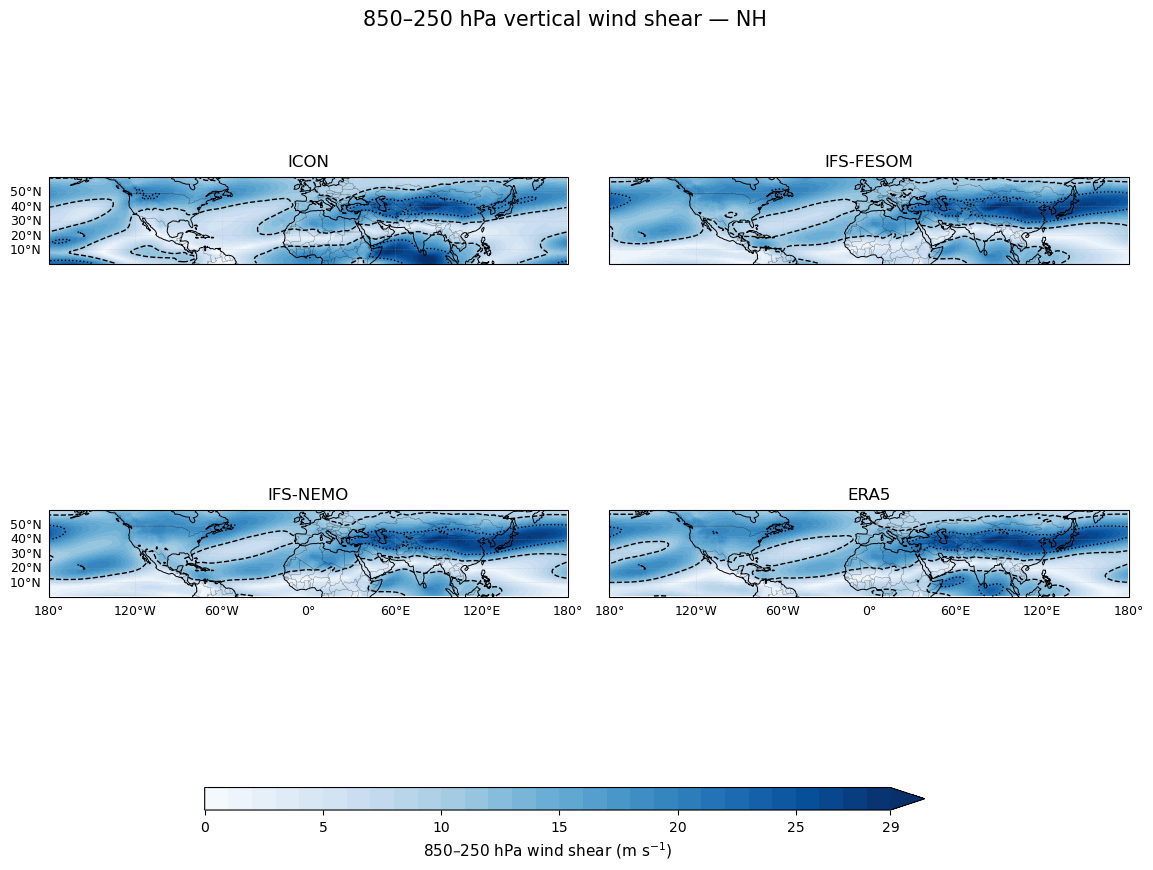

In [22]:
fig, axes = plot_Vd_roberts(shear, "NH")
plt.show()

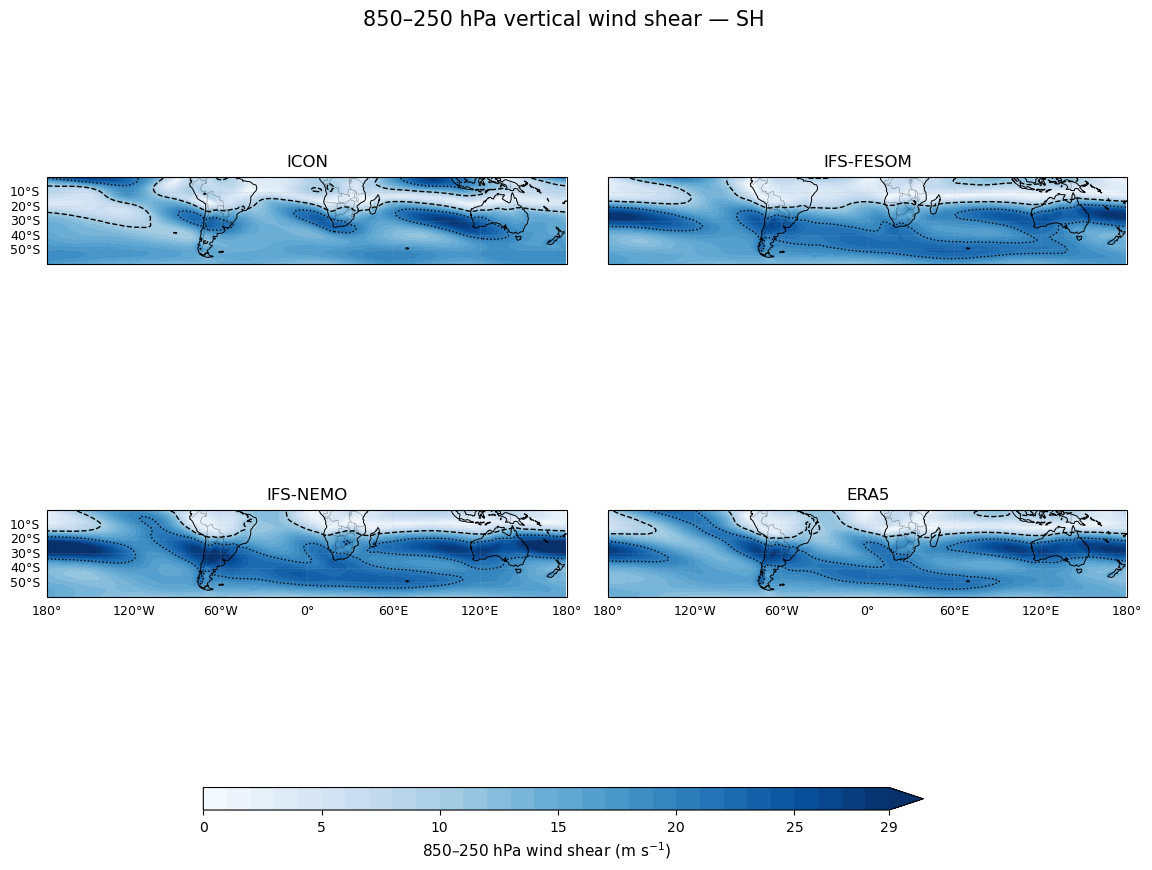

In [23]:
fig, axes = plot_Vd_roberts(shear, "SH")
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter


models = ["ICON", "IFS-FESOM", "IFS-NEMO", "ERA5"]


def plot_shear_component(shear, hemisphere, component):

    fig, axes = plt.subplots(
        2, 2,
        figsize=(12, 9),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    axes = axes.flatten()

    # ------------------------------------------------------
    # Hemisphere
    # ------------------------------------------------------

    if hemisphere == "NH":
        extent = [-180, 180, 0, 60]
        lat_ticks = np.arange(0, 61, 10)

    elif hemisphere == "SH":
        extent = [-180, 180, -60, 0]
        lat_ticks = np.arange(-60, 1, 10)

    else:
        raise ValueError("hemisphere must be 'NH' or 'SH'")

    lon_ticks = np.arange(-180, 181, 60)

    # ------------------------------------------------------
    # Find common symmetric colour scale
    # ------------------------------------------------------

    max_abs = 0

    for model in models:

        data = shear[model][hemisphere][component]

        max_abs = max(
            max_abs,
            float(np.nanmax(np.abs(data)))
        )

    # Round up to a convenient value
    max_abs = np.ceil(max_abs / 5) * 5

    levels = np.linspace(
        -max_abs,
        max_abs,
        31
    )

    cf = None

    # ------------------------------------------------------
    # Plot models
    # ------------------------------------------------------

    for i, (ax, model) in enumerate(zip(axes, models)):

        data = shear[model][hemisphere][component]

        # Convert longitude 0–360 -> -180–180
        lon = ((data.lon + 180) % 360) - 180

        data_plot = (
            data
            .assign_coords(lon=lon)
            .sortby("lon")
        )

        # --------------------------------------------------
        # Filled component
        # --------------------------------------------------

        cf = ax.contourf(
            data_plot.lon,
            data_plot.lat,
            data_plot,
            levels=levels,
            cmap="RdBu_r",
            vmin=-max_abs,
            vmax=max_abs,
            extend="both",
            transform=ccrs.PlateCarree()
        )

        # --------------------------------------------------
        # Zero contour
        # --------------------------------------------------

        ax.contour(
            data_plot.lon,
            data_plot.lat,
            data_plot,
            levels=[0],
            colors="black",
            linewidths=0.9,
            transform=ccrs.PlateCarree()
        )

        # --------------------------------------------------
        # Map
        # --------------------------------------------------

        ax.set_extent(
            extent,
            crs=ccrs.PlateCarree()
        )

        ax.coastlines(linewidth=0.7)

        ax.add_feature(
            cfeature.BORDERS,
            linewidth=0.3,
            alpha=0.5
        )

        # --------------------------------------------------
        # Gridlines
        # --------------------------------------------------

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.4,
            linestyle=":",
            alpha=0.6,
            xlocs=lon_ticks,
            ylocs=lat_ticks
        )

        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()

        gl.top_labels = False
        gl.right_labels = False

        # Latitude labels only on left column
        if i % 2 == 1:
            gl.left_labels = False

        # Longitude labels only on bottom row
        if i < 2:
            gl.bottom_labels = False

        gl.xlabel_style = {"size": 9}
        gl.ylabel_style = {"size": 9}

        ax.set_title(
            model,
            fontsize=12,
            pad=8
        )

    # ------------------------------------------------------
    # Figure title
    # ------------------------------------------------------

    if component == "ud":
        component_label = r"$u_{850} - u_{250}$"

    elif component == "vd":
        component_label = r"$v_{850} - v_{250}$"

    else:
        raise ValueError("component must be 'ud' or 'vd'")

    fig.suptitle(
        f"{component_label} — 850–250 hPa wind shear — {hemisphere}",
        fontsize=15,
        y=0.97
    )

    # ------------------------------------------------------
    # Leave dedicated space below maps
    # ------------------------------------------------------

    fig.subplots_adjust(
        left=0.07,
        right=0.97,
        bottom=0.20,
        top=0.90,
        wspace=0.08,
        hspace=0.03
    )

    # ------------------------------------------------------
    # Dedicated colourbar
    # ------------------------------------------------------

    cbar_ax = fig.add_axes([
        0.20,
        0.08,
        0.60,
        0.025
    ])

    cbar = fig.colorbar(
        cf,
        cax=cbar_ax,
        orientation="horizontal",
        ticks=np.linspace(
            -max_abs,
            max_abs,
            7
        )
    )

    cbar.set_label(
        f"{component_label} (m s$^{{-1}}$)",
        fontsize=11
    )

    return fig, axes

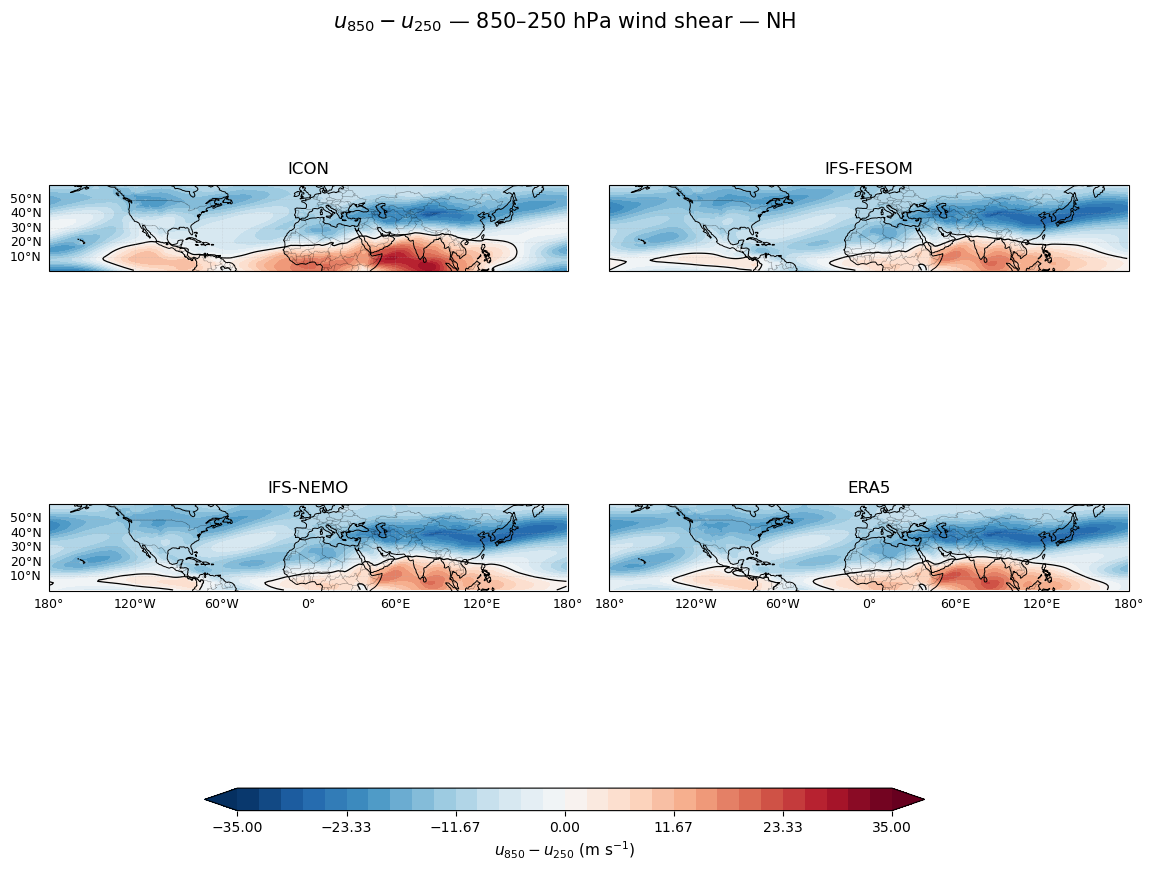

In [31]:
fig_ud_NH, axes = plot_shear_component(
    shear,
    "NH",
    "ud"
)

plt.show()

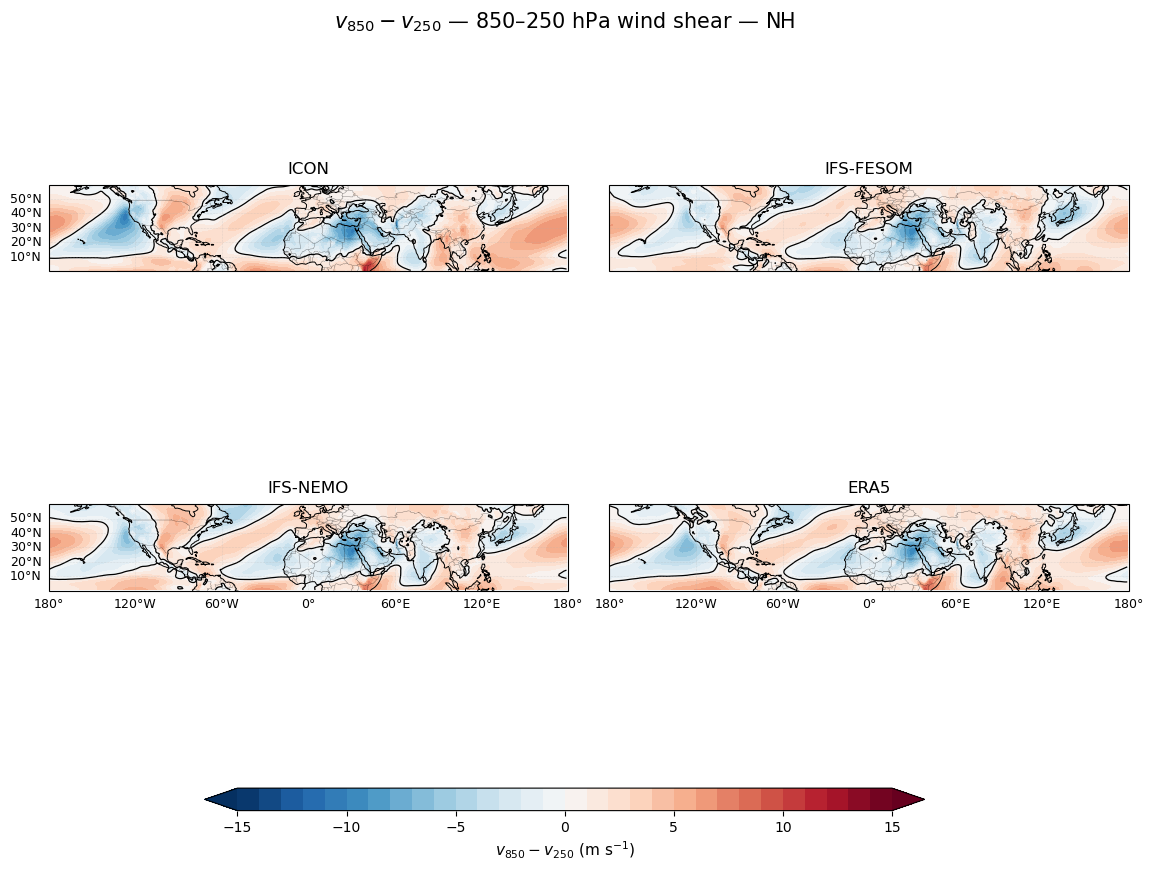

In [32]:
fig_ud_NH, axes = plot_shear_component(
    shear,
    "NH",
    "vd"
)

plt.show()

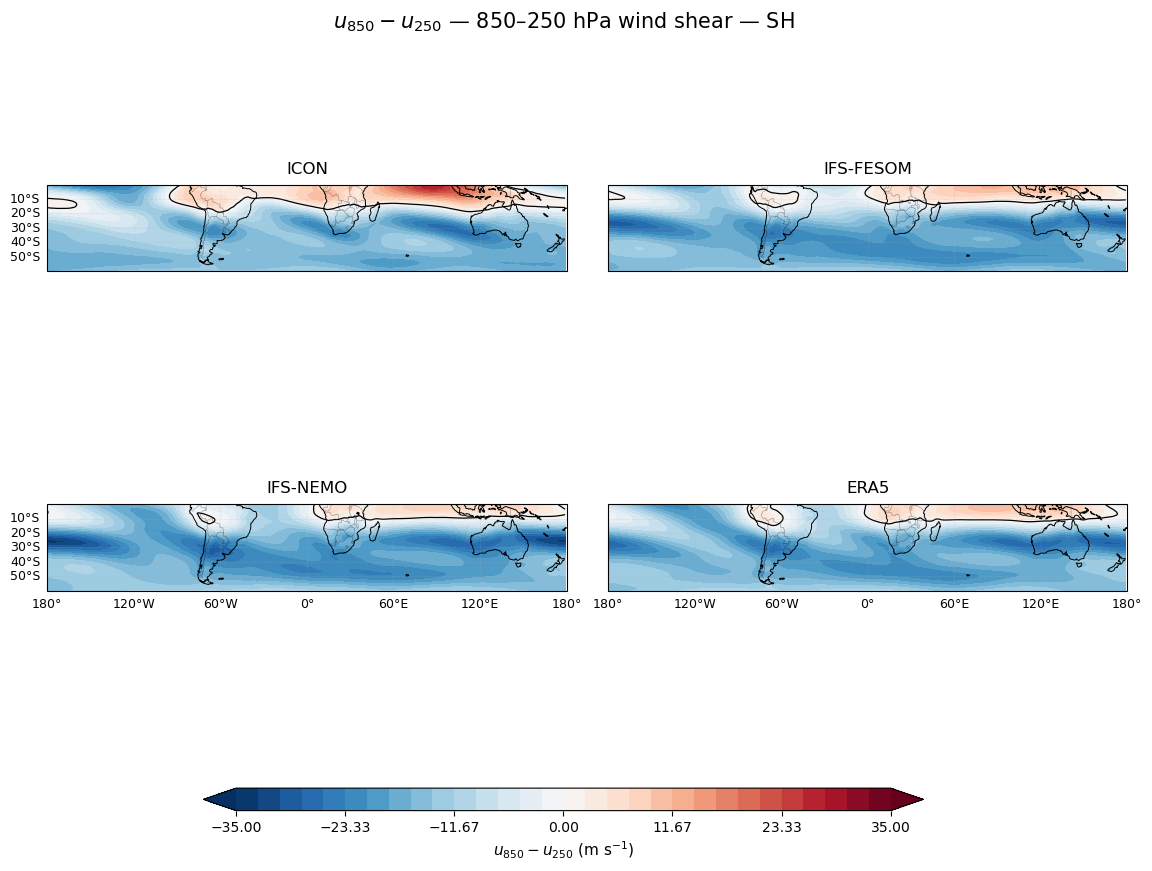

In [33]:
fig_ud_NH, axes = plot_shear_component(
    shear,
    "SH",
    "ud"
)

plt.show()

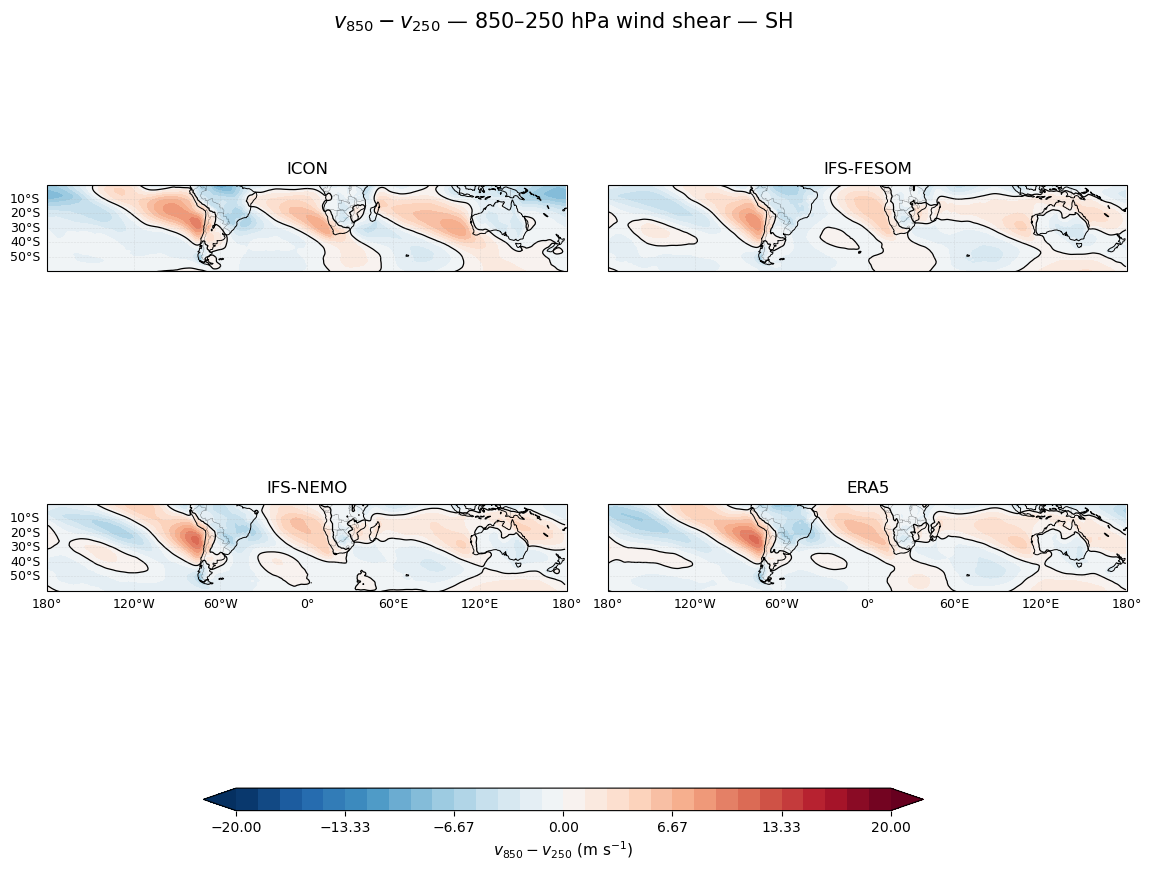

In [34]:
fig_ud_NH, axes = plot_shear_component(
    shear,
    "SH",
    "vd"
)

plt.show()

In [ ]:
client.shutdown()
cluster.close()